# NEW TOTAL DATA VAKSIN

In [ ]:
import pandas as pd

df_indobert = pd.read_csv("indonesia_gelap_checkpoint_gpt54_sentiment.csv", low_memory=False)
df_indobert.shape

(10000, 23)

In [16]:
df_indobert = df_indobert[["cleaned_text", "indobert_label"]].drop_duplicates()
df_indobert.head()

,cleaned_text,indobert_label
0,ASTAGHFIRULLAHALADZIM. Sore ini 28 agustus ter...,neutral
1,Perempuan mengalami kekerasan pada aksi Demo d...,negative
2,Jelas banget ini dia keluarin pistol.. Bahaya ...,negative
3,Isu merupakan narasi negatif yang diciptakan o...,negative
4,Salah satu tuntutan yang ada pada di Februari ...,negative


In [17]:
df_new = pd.read_csv("total_data_cleaned_indonesia_gelap.csv", low_memory=False)

df_new.shape

(600270, 54)

In [18]:
df_new = df_new[["cleaned_text", "final_sentiment"]].drop_duplicates()
df_new.head()

,cleaned_text,final_sentiment
0,INDONESIA GELAP INDONESIA MENCEKAM HIMBAUAN: B...,neutral
1,Indonesia gelap,neutral
2,di bilang Indonesia gelap ngk percaya,neutral
3,bang kemana lu saat Indonesia butuh aktor Indo...,neutral
4,"""Indonesia gelap""",neutral


In [19]:
# join the two dataframes on the "cleaned_text" column, keep final_sentiment from new dataframe and indobert_label from indobert dataframe
df_joined = pd.merge(
    pd.DataFrame({"cleaned_text": df_indobert["cleaned_text"], "indobert_label": df_indobert["indobert_label"]}),
    pd.DataFrame({"cleaned_text": df_new["cleaned_text"], "final_sentiment": df_new["final_sentiment"]}),
    on="cleaned_text",
    how="inner",
).drop_duplicates()
df_joined.head()


,cleaned_text,indobert_label,final_sentiment
0,ASTAGHFIRULLAHALADZIM. Sore ini 28 agustus ter...,neutral,negative
1,Perempuan mengalami kekerasan pada aksi Demo d...,negative,negative
2,Perempuan mengalami kekerasan pada aksi Demo d...,negative,neutral
3,Jelas banget ini dia keluarin pistol.. Bahaya ...,negative,neutral
4,Isu merupakan narasi negatif yang diciptakan o...,negative,negative


=== PERBANDINGAN METODE SENTIMENT ===
  Method  Accuracy  Macro-F1   F1 Neg   F1 Neu   F1 Pos  Precision   Recall
IndoBERT  0.578546  0.456581 0.696021 0.446078 0.227642   0.466152 0.453273


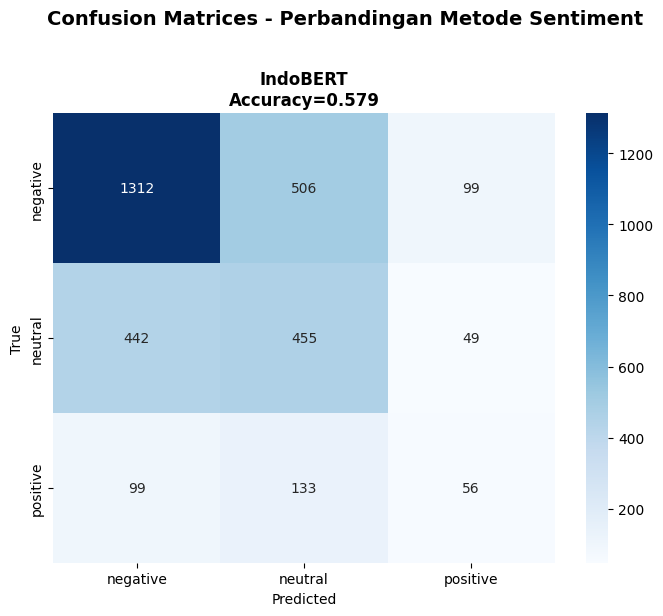

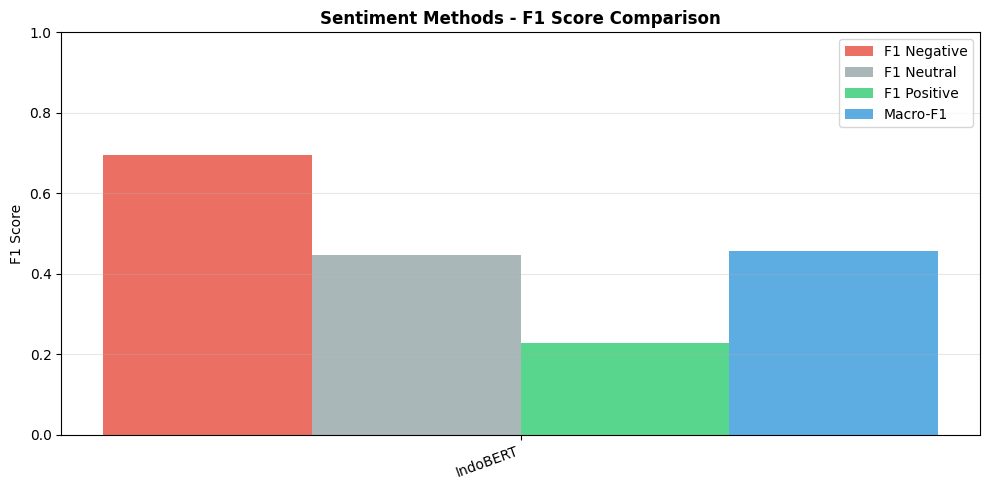

In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pakai dataframe hasil join sebagai sampel evaluasi
df_sample = df_joined.copy()
df = df_sample

# Tentukan kolom teks
text_col = None
for candidate in ['cleaned_text', 'full_text', 'text', 'content', 'tweet']:
    if candidate in df_sample.columns:
        text_col = candidate
        break

# 3.5c. Evaluasi semua metode sentimen + Confusion matrices + F1 bar chart

if text_col is not None:
    ref = df_sample['final_sentiment'].astype(str).str.lower()
    _label_norm = {'pro': 'positive', 'pos': 'positive',
                   'contra': 'negative', 'neg': 'negative', 'neu': 'neutral'}
    ref = ref.map(lambda x: _label_norm.get(x, x))
    labels_order = ['negative', 'neutral', 'positive']

    method_cols = {
        'IndoBERT': 'indobert_label',
    }
    predictions = {name: df_sample[col]
                   for name, col in method_cols.items() if col in df_sample.columns}

    missing_methods = [name for name, col in method_cols.items()
                       if col not in df_sample.columns]
    if missing_methods:
        print(f"Metode tidak tersedia (dilewati): {missing_methods}")

    if len(predictions) == 0:
        print("Tidak ada kolom prediksi sentimen. Evaluasi dilewati.")
    else:
        from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                                     recall_score, confusion_matrix)

        eval_rows = []
        conf_matrices = {}
        for name, preds in predictions.items():
            pred = preds.astype(str).str.lower().map(lambda x: _label_norm.get(x, x))
            acc = accuracy_score(ref, pred)
            f1_mac = f1_score(ref, pred, labels=labels_order, average='macro', zero_division=0)
            f1_per = f1_score(ref, pred, labels=labels_order, average=None, zero_division=0)
            prec = precision_score(ref, pred, labels=labels_order, average='macro', zero_division=0)
            rec = recall_score(ref, pred, labels=labels_order, average='macro', zero_division=0)
            cm = confusion_matrix(ref, pred, labels=labels_order)
            eval_rows.append({'Method': name, 'Accuracy': acc, 'Macro-F1': f1_mac,
                              'F1 Neg': f1_per[0], 'F1 Neu': f1_per[1], 'F1 Pos': f1_per[2],
                              'Precision': prec, 'Recall': rec})
            conf_matrices[name] = cm

        df_eval = pd.DataFrame(eval_rows)
        print("=== PERBANDINGAN METODE SENTIMENT ===")
        print(df_eval.to_string(index=False))

        # Confusion matrices
        n_methods = len(conf_matrices)
        ncols = min(3, n_methods)
        nrows = math.ceil(n_methods / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
        if n_methods == 1:
            axes = np.array([axes])

        for ax, (name, cm) in zip(np.array(axes).flat, conf_matrices.items()):
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=labels_order, yticklabels=labels_order)
            acc_v = accuracy_score(ref, predictions[name].astype(str).str.lower()
                                   .map(lambda x: _label_norm.get(x, x)))
            ax.set_title(f'{name}\nAccuracy={acc_v:.3f}', fontweight='bold')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')

        for ax in list(np.array(axes).flat)[len(conf_matrices):]:
            ax.axis('off')

        plt.suptitle('Confusion Matrices - Perbandingan Metode Sentiment',
                     fontweight='bold', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()

        # F1 bar chart
        fig, ax = plt.subplots(figsize=(max(10, 4 * len(df_eval)), 5))
        x = np.arange(len(df_eval))
        width = 0.2
        ax.bar(x - 1.5 * width, df_eval['F1 Neg'], width, label='F1 Negative', color='#e74c3c', alpha=0.8)
        ax.bar(x - 0.5 * width, df_eval['F1 Neu'], width, label='F1 Neutral', color='#95a5a6', alpha=0.8)
        ax.bar(x + 0.5 * width, df_eval['F1 Pos'], width, label='F1 Positive', color='#2ecc71', alpha=0.8)
        ax.bar(x + 1.5 * width, df_eval['Macro-F1'], width, label='Macro-F1', color='#3498db', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(df_eval['Method'], rotation=20, ha='right')
        ax.set_ylabel('F1 Score')
        ax.set_title('Sentiment Methods - F1 Score Comparison', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 1)
        plt.tight_layout()
        plt.show()
else:
    print("Evaluasi sentimen dilewati (kolom teks tidak ditemukan).")


In [21]:
# Ambil sample 10 data per sel error (off-diagonal) confusion matrix
import pandas as pd

labels_order = ['negative', 'neutral', 'positive']
_label_norm = {
    'pro': 'positive', 'pos': 'positive',
    'contra': 'negative', 'neg': 'negative', 'neu': 'neutral'
}

# Pastikan dataframe sumber ada
if 'df_joined' not in globals():
    raise ValueError("`df_joined` tidak ditemukan. Jalankan cell join dataframe terlebih dahulu.")

# Siapkan dataframe kerja
df_err = df_joined[['cleaned_text', 'indobert_label', 'final_sentiment']].copy()
df_err['indobert_label'] = df_err['indobert_label'].astype(str).str.lower().map(lambda x: _label_norm.get(x, x))
df_err['final_sentiment'] = df_err['final_sentiment'].astype(str).str.lower().map(lambda x: _label_norm.get(x, x))

# Filter hanya label yang valid
df_err = df_err[
    df_err['indobert_label'].isin(labels_order)
    & df_err['final_sentiment'].isin(labels_order)
]

# Ambil 10 sample untuk tiap pasangan true-pred yang salah (6 sel off-diagonal)
samples_per_error_cell = {}
sample_rows = []

for true_label in labels_order:
    for pred_label in labels_order:
        if true_label == pred_label:
            continue  # skip diagonal (prediksi benar)

        key = f"true={true_label} | pred={pred_label}"
        subset = df_err[
            (df_err['final_sentiment'] == true_label)
            & (df_err['indobert_label'] == pred_label)
        ][['cleaned_text', 'indobert_label', 'final_sentiment']]

        n_take = min(10, len(subset))
        sampled = subset.sample(n=n_take, random_state=42) if n_take > 0 else subset.copy()
        samples_per_error_cell[key] = sampled

        if n_take > 0:
            temp = sampled.copy()
            temp['cm_cell'] = key
            sample_rows.append(temp)

# Gabungkan semua sample agar mudah dilihat / diekspor
if sample_rows:
    df_error_samples = pd.concat(sample_rows, ignore_index=True)
    df_error_samples = df_error_samples[['cm_cell', 'cleaned_text', 'indobert_label', 'final_sentiment']]
else:
    df_error_samples = pd.DataFrame(columns=['cm_cell', 'cleaned_text', 'indobert_label', 'final_sentiment'])

print("Jumlah sample per cell error:")
for k, v in samples_per_error_cell.items():
    print(f"- {k}: {len(v)}")

print("\nPreview gabungan sample:")
df_error_samples.head(20)

Jumlah sample per cell error:
- true=negative | pred=neutral: 10
- true=negative | pred=positive: 10
- true=neutral | pred=negative: 10
- true=neutral | pred=positive: 10
- true=positive | pred=negative: 10
- true=positive | pred=neutral: 10

Preview gabungan sample:


,cm_cell,cleaned_text,indobert_label,final_sentiment
0,true=negative | pred=neutral,. Kejanggalan foto yg diklaim jokowi sebagai m...,neutral,negative
1,true=negative | pred=neutral,"Gas elpiji 3kg boleh langka, tapi memasak PENT...",neutral,negative
2,true=negative | pred=neutral,Cerita Sex Balas Budi Untuk Tante Serlly lang...,neutral,negative
3,true=negative | pred=neutral,"Ternate, mahasiswa dan jurnalis dipukul Satpol...",neutral,negative
4,true=negative | pred=neutral,Dulu abang pernah mewanti wanti indonesia gela...,neutral,negative
5,true=negative | pred=neutral,Apa sebutan utk Babi yg luar biasa? Hewan di g...,neutral,negative
6,true=negative | pred=neutral,"Dengan SDM unggul dan teknologi, Indonesia sia...",neutral,negative
7,true=negative | pred=neutral,"Selamat berjuang dan melawan. Stay safe, teman...",neutral,negative
8,true=negative | pred=neutral,"Pak Zulkifli panutan, Uya Kuya DPR RI, semoga ...",neutral,negative
9,true=negative | pred=neutral,"Kalau ada yang bilang Indonesia Gelap , Yang G...",neutral,negative


In [8]:
# 1) Simpan sample ke file baru + 2) tambah kolom kosong manual_label + 3) labeling interaktif
import os
import pandas as pd

if 'df_error_samples' not in globals():
    raise ValueError("`df_error_samples` belum ada. Jalankan cell sampling error terlebih dahulu.")

base_cols = ['cm_cell', 'cleaned_text', 'indobert_label', 'final_sentiment']
missing_cols = [c for c in base_cols if c not in df_error_samples.columns]
if missing_cols:
    raise ValueError(f"Kolom berikut belum ada di df_error_samples: {missing_cols}")

# File awal untuk proses labeling
samples_file = 'error_samples_for_labeling.csv'
labeled_file = 'error_samples_labeled.csv'

df_to_label = df_error_samples[base_cols].copy()
if 'manual_label' not in df_to_label.columns:
    df_to_label['manual_label'] = ''

# Simpan file sample baru (dengan manual_label kosong)
df_to_label.to_csv(samples_file, index=False, encoding='utf-8-sig')
print(f"File sample tersimpan: {samples_file} ({len(df_to_label)} baris)")

# Jika sudah pernah ada file labeled, lanjutkan dari file itu agar tidak mengulang dari awal
if os.path.exists(labeled_file):
    prev = pd.read_csv(labeled_file, dtype=str).fillna('')
    required = base_cols + ['manual_label']
    if all(c in prev.columns for c in required):
        df_work = prev[required].copy()
        print(f"Lanjut dari file existing: {labeled_file}")
    else:
        df_work = df_to_label[required].copy()
        print("Struktur file labeled lama tidak cocok, mulai dari sample terbaru.")
else:
    df_work = df_to_label[base_cols + ['manual_label']].copy()

valid_labels = {'positive', 'negative', 'neutral'}

print("\nMulai labeling manual.")
print("Input yang diterima: positive / negative / neutral")
print("Ketik 'skip' untuk lewati, 'exit' untuk berhenti lebih awal.\n")

for i in range(len(df_work)):
    current = str(df_work.at[i, 'manual_label']).strip().lower()
    if current in valid_labels:
        continue  # sudah terisi valid, lewati

    print("=" * 80)
    print(f"Data ke-{i+1}/{len(df_work)}")
    print(f"cm_cell         : {df_work.at[i, 'cm_cell']}")
    print(f"indobert_label       : {df_work.at[i, 'indobert_label']}")
    print(f"final_sentiment : {df_work.at[i, 'final_sentiment']}")
    print(f"cleaned_text    : {df_work.at[i, 'cleaned_text']}")

    while True:
        user_in = input("manual_label [positive/negative/neutral | skip | exit]: ").strip().lower()
        if user_in in valid_labels:
            df_work.at[i, 'manual_label'] = user_in
            break
        if user_in == 'skip':
            break
        if user_in == 'exit':
            print("Proses dihentikan oleh user.")
            df_work.to_csv(labeled_file, index=False, encoding='utf-8-sig')
            print(f"Progress tersimpan ke: {labeled_file}")
            raise SystemExit
        print("Input tidak valid. Gunakan: positive, negative, neutral, skip, atau exit.")

# Simpan hasil akhir
df_work.to_csv(labeled_file, index=False, encoding='utf-8-sig')
print(f"\nSelesai. Hasil tersimpan ke: {labeled_file}")
print("Kolom output: cm_cell, cleaned_text, indobert_label, final_sentiment, manual_label")

# Preview hasil
df_work.head(10)

File sample tersimpan: error_samples_for_labeling.csv (60 baris)
Struktur file labeled lama tidak cocok, mulai dari sample terbaru.

Mulai labeling manual.
Input yang diterima: positive / negative / neutral
Ketik 'skip' untuk lewati, 'exit' untuk berhenti lebih awal.

Data ke-1/60
cm_cell         : true=negative | pred=neutral
indobert_label       : neutral
final_sentiment : negative
cleaned_text    : . Kejanggalan foto yg diklaim jokowi sebagai miliknya digunakan untuk berbagai dokumen. . . .
Data ke-2/60
cm_cell         : true=negative | pred=neutral
indobert_label       : neutral
final_sentiment : negative
cleaned_text    : Gas elpiji 3kg boleh langka, tapi memasak PENTOL tetep harus terlaksana.
Data ke-3/60
cm_cell         : true=negative | pred=neutral
indobert_label       : neutral
final_sentiment : negative
cleaned_text    : Cerita Sex Balas Budi Untuk Tante Serlly  langsung gabung aja ya sayangku >>
Data ke-4/60
cm_cell         : true=negative | pred=neutral
indobert_label     

,cm_cell,cleaned_text,indobert_label,final_sentiment,manual_label
0,true=negative | pred=neutral,. Kejanggalan foto yg diklaim jokowi sebagai m...,neutral,negative,neutral
1,true=negative | pred=neutral,"Gas elpiji 3kg boleh langka, tapi memasak PENT...",neutral,negative,neutral
2,true=negative | pred=neutral,Cerita Sex Balas Budi Untuk Tante Serlly lang...,neutral,negative,negative
3,true=negative | pred=neutral,"Ternate, mahasiswa dan jurnalis dipukul Satpol...",neutral,negative,negative
4,true=negative | pred=neutral,Dulu abang pernah mewanti wanti indonesia gela...,neutral,negative,neutral
5,true=negative | pred=neutral,Apa sebutan utk Babi yg luar biasa? Hewan di g...,neutral,negative,negative
6,true=negative | pred=neutral,"Dengan SDM unggul dan teknologi, Indonesia sia...",neutral,negative,positive
7,true=negative | pred=neutral,"Selamat berjuang dan melawan. Stay safe, teman...",neutral,negative,positive
8,true=negative | pred=neutral,"Pak Zulkifli panutan, Uya Kuya DPR RI, semoga ...",neutral,negative,negative
9,true=negative | pred=neutral,"Kalau ada yang bilang Indonesia Gelap , Yang G...",neutral,negative,negative


In [23]:
# 1) Simpan sample ke file baru + 2) tambah kolom kosong manual_label + 3) labeling interaktif
import os
import pandas as pd

if 'df_error_samples' not in globals():
    raise ValueError("`df_error_samples` belum ada. Jalankan cell sampling error terlebih dahulu.")

base_cols = ['cm_cell', 'cleaned_text', 'indobert_label', 'final_sentiment']
missing_cols = [c for c in base_cols if c not in df_error_samples.columns]
if missing_cols:
    raise ValueError(f"Kolom berikut belum ada di df_error_samples: {missing_cols}")

# File awal untuk proses labeling
samples_file = 'error_samples_for_labeling.csv'
labeled_file = 'error_samples_labeled.csv'

df_to_label = df_error_samples[base_cols].copy()
if 'manual_label' not in df_to_label.columns:
    df_to_label['manual_label'] = ''

# Simpan file sample baru (dengan manual_label kosong)
df_to_label.to_csv(samples_file, index=False, encoding='utf-8-sig')
print(f"File sample tersimpan: {samples_file} ({len(df_to_label)} baris)")

# Jika sudah pernah ada file labeled, lanjutkan dari file itu agar tidak mengulang dari awal
if os.path.exists(labeled_file):
    prev = pd.read_csv(labeled_file, dtype=str).fillna('')
    required = base_cols + ['manual_label']
    if all(c in prev.columns for c in required):
        df_work = prev[required].copy()
        print(f"Lanjut dari file existing: {labeled_file}")
    else:
        df_work = df_to_label[required].copy()
        print("Struktur file labeled lama tidak cocok, mulai dari sample terbaru.")
else:
    df_work = df_to_label[base_cols + ['manual_label']].copy()

valid_labels = {'positive', 'negative', 'neutral'}

print("\nMulai labeling manual.")
print("Input yang diterima: positive / negative / neutral")
print("Ketik 'skip' untuk lewati, 'exit' untuk berhenti lebih awal.\n")

for i in range(len(df_work)):
    current = str(df_work.at[i, 'manual_label']).strip().lower()
    if current in valid_labels:
        continue  # sudah terisi valid, lewati

    print("=" * 80)
    print(f"Data ke-{i+1}/{len(df_work)}")
    print(f"cm_cell         : {df_work.at[i, 'cm_cell']}")
    print(f"indobert_label       : {df_work.at[i, 'indobert_label']}")
    print(f"final_sentiment : {df_work.at[i, 'final_sentiment']}")
    print(f"cleaned_text    : {df_work.at[i, 'cleaned_text']}")

    while True:
        user_in = input("manual_label [positive/negative/neutral | skip | exit]: ").strip().lower()
        if user_in in valid_labels:
            df_work.at[i, 'manual_label'] = user_in
            break
        if user_in == 'skip':
            break
        if user_in == 'exit':
            print("Proses dihentikan oleh user.")
            df_work.to_csv(labeled_file, index=False, encoding='utf-8-sig')
            print(f"Progress tersimpan ke: {labeled_file}")
            raise SystemExit
        print("Input tidak valid. Gunakan: positive, negative, neutral, skip, atau exit.")

# Simpan hasil akhir
df_work.to_csv(labeled_file, index=False, encoding='utf-8-sig')
print(f"\nSelesai. Hasil tersimpan ke: {labeled_file}")
print("Kolom output: cm_cell, cleaned_text, indobert_label, final_sentiment, manual_label")

# Preview hasil
df_work.head(10)

File sample tersimpan: error_samples_for_labeling.csv (60 baris)
Lanjut dari file existing: error_samples_labeled.csv

Mulai labeling manual.
Input yang diterima: positive / negative / neutral
Ketik 'skip' untuk lewati, 'exit' untuk berhenti lebih awal.


Selesai. Hasil tersimpan ke: error_samples_labeled.csv
Kolom output: cm_cell, cleaned_text, indobert_label, final_sentiment, manual_label


,cm_cell,cleaned_text,indobert_label,final_sentiment,manual_label
0,true=negative | pred=neutral,. Kejanggalan foto yg diklaim jokowi sebagai m...,neutral,negative,neutral
1,true=negative | pred=neutral,"Gas elpiji 3kg boleh langka, tapi memasak PENT...",neutral,negative,neutral
2,true=negative | pred=neutral,Cerita Sex Balas Budi Untuk Tante Serlly lang...,neutral,negative,negative
3,true=negative | pred=neutral,"Ternate, mahasiswa dan jurnalis dipukul Satpol...",neutral,negative,negative
4,true=negative | pred=neutral,Dulu abang pernah mewanti wanti indonesia gela...,neutral,negative,neutral
5,true=negative | pred=neutral,Apa sebutan utk Babi yg luar biasa? Hewan di g...,neutral,negative,negative
6,true=negative | pred=neutral,"Dengan SDM unggul dan teknologi, Indonesia sia...",neutral,negative,positive
7,true=negative | pred=neutral,"Selamat berjuang dan melawan. Stay safe, teman...",neutral,negative,positive
8,true=negative | pred=neutral,"Pak Zulkifli panutan, Uya Kuya DPR RI, semoga ...",neutral,negative,negative
9,true=negative | pred=neutral,"Kalau ada yang bilang Indonesia Gelap , Yang G...",neutral,negative,negative


In [ ]:
if 'df_work' not in globals():
    raise ValueError("`df_work` belum ada. Jalankan cell labeling terlebih dahulu.")
valid_labels = {'positive', 'negative', 'neutral'}
df_eval = df_work[df_work['manual_label'].isin(valid_labels) & df_work['indobert_label'].isin(valid_labels)].copy()
accuracy = (df_eval['indobert_label'] == df_eval['manual_label']).mean()
print(f"Keakuratan indobert label terhadap manual label: {accuracy:.2%}")

In [ ]:
if 'df_work' not in globals():
    raise ValueError("`df_work` belum ada. Jalankan cell labeling terlebih dahulu.")
valid_labels = {'positive', 'negative', 'neutral'}
df_eval = df_work[df_work['manual_label'].isin(valid_labels) & df_work['final_sentiment'].isin(valid_labels)].copy()
accuracy = (df_eval['final_sentiment'] == df_eval['manual_label']).mean()
print(f"Keakuratan Final Sentiment terhadap manual label: {accuracy:.2%}")